# XOR

In [1]:
import numpy as np
#데이터 준비
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])
#모델의 형상
#입력뉴런과 출력뉴런의 갯수는 프로그래머가 정할 수 없다.
#입력뉴런의 갯수는 입력 데이터의 피처수
#출력뉴런의 갯수는 타겟데이터의 값에 따라 결정
#은닉층의 계층수와 뉴런의 수는 프로그래머가 정한다.
in_n=2
h_n=2
out_n=1
#예측값 준비(초기 가중치)
W1=2*np.random.random((in_n,h_n))-1
W2=2*np.random.random((h_n,out_n))-1

In [2]:
X.shape,W1.shape,W2.shape,y.shape

((4, 2), (2, 2), (2, 1), (4, 1))

In [ ]:
#활성화 함수
def act_f(z):#시그모이드 활성화 함수
    return 1/(1+np.exp(-z))
def act_f_d(x):#시그모이드 활성화 함수 도함수
    return x*(1-x) # 미분값

순전파 연산(초기 가중치를 이용한)

In [5]:
#모델 형성
#입력->은닉
#입력층
l_in=X
#1번 계층 
z1=l_in@W1#입력값과 히든층의 가중치 내적연산
h1=act_f(z1)#z값 활성화 함수 연산
#은닉->출력
#2번 계층
z2=h1@W2#히든층출력과 출력층의 가중치 내적연산
l_out=act_f(z2)#결과 출력을 위한 연산 (출력함수==활성화함수)
print("출력:\n",l_out)#예측값

출력:
 [[0.51052973]
 [0.54909868]
 [0.51161355]
 [0.55020498]]


오차

In [6]:
out_err=y-l_out
out_err

array([[-0.51052973],
       [ 0.45090132],
       [ 0.48838645],
       [-0.55020498]])

오차 역전파

In [7]:
#출력오차
out_err=y-l_out
#출력 오차 전달
l_out_d=act_f_d(l_out)*out_err
#히든오차
h_err=l_out_d@W2.T
#히든 오차 전달
h_l_d=act_f_d(h1)*h_err
#최적화
W2-=0.2*(h1.T@l_out_d) # 기울기값
W1-=0.2*(l_in.T@h_l_d)

통합 정리

In [9]:
import numpy as np
from tqdm import tqdm
#데이터 준비
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])
#모델의 형상
in_n=2
h_n=3
out_n=1
#예측값 준비(초기 가중치)
W1=2*np.random.random((in_n,h_n))-1
W2=2*np.random.random((h_n,out_n))-1
#활성화 함수
def act_f(z):
    return 1/(1+np.exp(-z))
#도함수
def act_f_d(x):
    return x*(1-x)
#순방향 연산
l_in=X
z1=l_in@W1
h1=act_f(z1)
z2=h1@W2
l_out=act_f(z2)
print("학습전\n",l_out>=0.5)

학습률=0.5
반복수=10000
#학습
for i in tqdm(range(반복수)):
    #예측값 도출
    l_in=X
    z1=l_in@W1
    h1=act_f(z1)
    z2=h1@W2
    l_out=act_f(z2)
    #오차 도출
    out_err=l_out-y
    #오차 역전파
    l_out_d=act_f_d(l_out)*out_err
    h_err=l_out_d@W2.T
    h_l_d=act_f_d(h1)*h_err
    #가중치 연산
    W2 -= 학습률*(h1.T@l_out_d)
    W1 -= 학습률*(l_in.T@h_l_d)
    
l_in=X
z1=l_in@W1
h1=act_f(z1)
z2=h1@W2
l_out=act_f(z2)    
print("학습후\n",l_out>=0.5)

학습전
 [[ True]
 [ True]
 [ True]
 [ True]]


100%|██████████| 10000/10000 [00:00<00:00, 29273.36it/s]

학습후
 [[False]
 [ True]
 [ True]
 [False]]


In [10]:
h1.T.shape,l_out_d.shape

((3, 4), (4, 1))

In [11]:
l_in.T.shape,h_l_d.shape

((2, 4), (4, 3))

In [12]:
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,0])

In [13]:
class Two_net:
    def __init__(self,hidden_units=10,lr=0.1):
        self.hidden_units=hidden_units
        self.w1=None
        self.b1=None
        self.w2=None
        self.b2=None
        self.losses=[]
        self.lr=lr
    def forpass(self,X):
        z1=X@self.w1+self.b1
        a1=self.act_f_relu(z1)
        z2=a1@self.w2+self.b2
        return z1,a1,z2
        
    def act_f_relu(self,z):
        return np.maximum(0,z)
        
    def act_f_sigmoid(self,z):
        z=np.clip(z,-100,None)
        return 1/(1+np.exp(-z))

    def backpass(self,X,a1,z1,z2,y):
        py=self.act_f_sigmoid(z2)
        err_output = py-y

        w2_g = (a1.T@err_output)/len(X)
        b2_g = np.mean(err_output)

        da1 = err_output@self.w2.T
        dz1 = da1*(z1>0)

        w1_g = (X.T@dz1) /len(X)
        b1_g = np.mean(dz1,axis=0)

        return w1_g,b1_g,w2_g,b2_g
    def fit(self,X,y,epoch=1000,batch_size=4):
        n_samples,n_features = X.shape
        np.random.seed(42)
        #가중치 초기화 He 초기화
        self.w1 = np.random.randn(n_features,self.hidden_units)*np.sqrt(2./n_features)
        self.b1 = np.zeros(self.hidden_units)
        self.w2 = np.random.randn(self.hidden_units,1)*np.sqrt(2./self.hidden_units)
        self.b2 = 0

        for _ in range(epoch):
            idx=np.random.permutation(n_samples)
            X_sf=X[idx]
            y_sf=y[idx].reshape(-1,1)
            loss=0
            for start in range(0,n_samples,batch_size):
                end = start+batch_size
                X_batch = X_sf[start:end]
                y_batch = y_sf[start:end]

                z1,a1,z2 = self.forpass(X_batch)
                py = self.act_f_sigmoid(z2)

                w1_g,b1_g,w2_g,b2_g = self.backpass(X_batch,a1,z1,z2,y_batch)

                self.w1 -= self.lr*w1_g
                self.b1 -= self.lr*b1_g
                self.w2 -= self.lr*w2_g
                self.b2 -= self.lr*b2_g

                py = np.clip(py,1e-10,1-1e-10)
                batch_loss=-np.mean(y_batch*np.log(py)+(1-y_batch)*np.log(1-py))
                loss+= batch_loss*len(X_batch)
            self.losses.append(loss/n_samples)
            
    def predict(self,X):
        _,_,z2=self.forpass(X)
        py = self.act_f_sigmoid(z2)
        return (py>0.5).astype(int)
    def score(self,X,y):
        return np.mean(self.predict(X)==y)

예측값: [0 1 1 0]
실제값: [0 1 1 0]
정확도 1.0


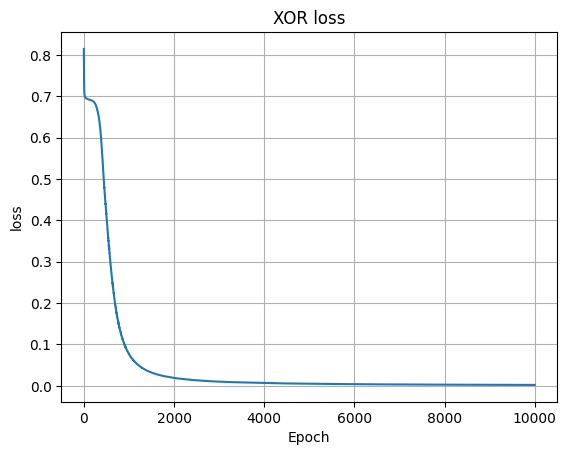

In [14]:
import matplotlib.pyplot as plt
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

m=Two_net(4)
m.fit(X,y,epoch=10000,batch_size=4)

py=m.predict(X)
print("예측값:",py.reshape(-1))
print("실제값:",y.reshape(-1))
print("정확도",m.score(X,y))

plt.plot(m.losses)
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('XOR loss')
plt.grid(True)
plt.show()

In [18]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   - -------------------------------------- 8.9/332.0 MB 51.2 MB/s eta 0:00:07
   --- ------------------------------------ 27.0/332.0 MB 69.0 MB/s eta 0:00:05
   ----- ---------------------------------- 43.8/332.0 MB 72.1 MB/s eta 0:00:05
   ------ --------------------------------- 57.7/332.0 

In [ ]:
from keras import models, layers, losses, optimizers, utils,preprocessing,activations

c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\USER\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in t

In [20]:
from keras.models import Sequential,Model
from keras.layers import Input,Dense
from keras.losses import binary_crossentropy,categorical_crossentropy,mean_squared_error,mean_absolute_error
from keras.optimizers import SGD

In [21]:
X.shape

(4, 2)

In [22]:
m=Sequential()#케이스
m.add(Input(shape=(2,)))
m.add(Dense(3,activation='relu'))
m.add(Dense(1,activation='sigmoid'))
m.compile(loss='binary_crossentropy')
m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
hy=m.fit(X,y,epochs=1000,batch_size=4)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - loss: 0.6571
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.6564
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.6555
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.6550
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6545
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6541
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6536
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.6533
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.6529
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6525
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.6522
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6519
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6515
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6512
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.6509
Epo

In [24]:
m.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([[0.49970165],
       [0.49970165],
       [0.8377789 ],
       [0.16258076]], dtype=float32)

In [ ]:
# 결과에 만족스럽지 않으면 하이퍼파라미터 조정, 활성화, 레이어 등의 조정 등을 할 수 있음

In [43]:
from keras.datasets import mnist, imdb, fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.losses import mean_squared_error, binary_crossentropy, categorical_crossentropy, sparse_categorical_crossentropy

In [28]:
data = imdb.load_data()
len(data)

2

In [31]:
tr_data, tt_data = data
len(tr_data)

2

In [32]:
X, y = tr_data
X

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1

In [33]:
len(X[0]), len(X[1])

(218, 189)

In [34]:
data = mnist.load_data()
tr_data, tt_data = data
len(tr_data)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2

In [35]:
X, y = tr_data
X.shape

(60000, 28, 28)

In [36]:
import numpy as np

In [37]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [38]:
X.reshape(-1,28,28,1).shape

(60000, 28, 28, 1)

In [39]:
X = X.reshape(-1,28*28)
X.shape, y.shape

((60000, 784), (60000,))

In [42]:
from keras.utils import to_categorical
e_y = to_categorical(y)
e_y.shape

(60000, 10)

In [46]:
m = Sequential()
m.add(Input(shape=(28*28,))) # 입력층
m.add(Dense(10, activation='relu'))
m.add(Dense(10, activation='softmax'))
m.compile(loss='categorical_crossentropy') # 반드시 y값이 인코딩 되어야 사용 가능함
m.summary()
m.fit(X, e_y)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 952us/step - loss: 1.9348


In [ ]:
m = Sequential()
m.add(Input(shape=(28*28,)))
m.add(Dense(10, activation='relu'))
m.add(Dense(10, activation='softmax'))
m.compile(loss='sparse_categorical_crossentropy') # 자동으로 y를 인코딩적용함
m.summary()
m.fit(X,y)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 970us/step - loss: 2.2072


In [48]:
m.predict(X[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[0.12107424, 0.13519894, 0.04372879, 0.12341606, 0.11799195,
        0.06406824, 0.11884356, 0.03935395, 0.11931746, 0.11700687],
       [0.12107424, 0.13519894, 0.04372879, 0.12341606, 0.11799195,
        0.06406824, 0.11884356, 0.03935395, 0.11931746, 0.11700687],
       [0.12107424, 0.13519894, 0.04372879, 0.12341606, 0.11799195,
        0.06406824, 0.11884356, 0.03935395, 0.11931746, 0.11700687],
       [0.12107424, 0.13519894, 0.04372879, 0.12341606, 0.11799195,
        0.06406824, 0.11884356, 0.03935395, 0.11931746, 0.11700687],
       [0.12107424, 0.13519894, 0.04372879, 0.12341606, 0.11799195,
        0.06406824, 0.11884356, 0.03935395, 0.11931746, 0.11700687]],
      dtype=float32)

In [51]:
m.evaluate(X, y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - loss: 1.8383


1.8382762670516968

In [54]:
np.argmax(m.predict(X[:1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


np.int64(1)

In [56]:
y[1]

np.uint8(0)

In [58]:
# Q1 mnist(필기체 인식 데이터) 분류기 만들기(완전연결계층을 이용하여)

In [59]:
from keras.layers import Dense, Input
from keras.models import Sequential
from keras.datasets import mnist

In [65]:
data = mnist.load_data()
len(data)
len(data[0]), len(data[1])
len(data[0][0]), len(data[1][0])

(60000, 10000)

In [92]:
len(data)

2

In [93]:
len(data[0]), len(data[1])

(2, 2)

In [66]:
tr, tt = data
X, y = tr
X.shape, y.shape

((60000, 28, 28), (60000,))

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, shuffle=True)
X_train.shape, y_train.shape

((42000, 28, 28), (42000,))

In [76]:
X_train = X_train.reshape(-1,28*28)
X_train.shape

(42000, 784)

In [ ]:
model = Sequential() # 건축 바닥 구매
model.add(Input(shape=(784,))) # 기둥 설치
model.add(Dense(20)) # 바닥에 받칠 바닥 블럭
model.add(Dense(10, activation='softmax')) # 더 큰 바닥 블럭
model.compile(loss='sparse_categorical_crossentropy')
model.summary()
model.fit(X_train, y_train)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 12.5382


In [84]:
model.predict(X_train[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [88]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [85]:
y_train[0]

np.uint8(2)

In [91]:
model.evaluate(X_test.reshape(-1,28*28), y_test)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - loss: 6.6621


6.662125110626221

In [94]:
# 정답용 코드
# 작업준비
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from keras.datasets import mnist

In [95]:
# 데이터 수집
(tr_x, tr_y), (tt_x, tt_y) = mnist.load_data()

In [96]:
# 데이터 전처리
e_X = tr_x.reshape(-1,28*28)
e_y = to_categorical(tr_y)

In [97]:
# 모델 설계 학습
m = Sequential()
m.add(Input(shape=(784,)))
m.add(Dense(10, activation='relu'))
m.add(Dense(10, activation='softmax'))
m.compile(loss='categorical_crossentropy')

In [98]:
hy = m.fit(e_X, e_y, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 938us/step - loss: 2.1126
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step - loss: 1.5282
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step - loss: 1.2990
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.2227
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 945us/step - loss: 1.1799
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1258  
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 948us/step - loss: 1.0438
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 944us/step - loss: 1.0058
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - loss: 0.9964
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9614
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9293
Epoch 12/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8908
Epoch 13/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8462
Epoch 14/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7815

In [105]:
hy.history.keys()

dict_keys(['loss'])

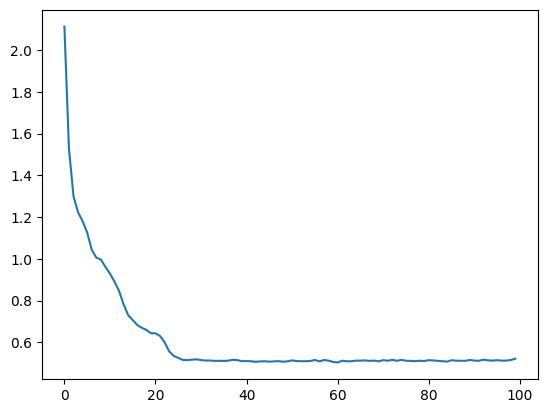

In [109]:
import matplotlib.pyplot as plt
plt.plot(hy.history['loss'])
plt.show()

In [110]:
m.evaluate(e_X, e_y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - loss: 0.4985


0.4985139071941376

In [111]:
# 작업준비
# 데이터 분석
# 1. 데이터 수집
# 2. 데이터 전처리(EDA)
# 3. 모델 설계
# 4. 모델 학습
# 5. 모델 검증 및 테스트

In [ ]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Dropout, SimpleRNN, LSTM, GRU, BatchNormalization
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

In [127]:
# from keras.datasets 해당 코드의 데이터셋은 직접 다뤄볼 것. 그리고 imdb는 텍스트를 직접 정제해서 사용해볼 것임 
# 1. 데이터 수집
from keras.datasets import mnist
(tr_x, tr_y), (tt_x, tt_y) = mnist.load_data()
tr_x.shape, tr_y.shape, tt_x.shape, tt_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

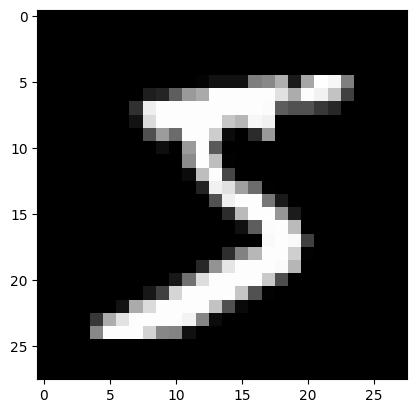

In [128]:
# 2. 데이터 전처리(EDA)
import matplotlib.pyplot as plt
plt.imshow(tr_x[0], cmap='gray')

In [121]:
tr_x[0].shape

(28, 28)

In [140]:
(X,y),(_,_) = mnist.load_data()
x_data, tt_x, y_data, tt_y = train_test_split(X, y, test_size=.3, stratify=y) # y 데이터 기준으로 비율 유지
print(x_data.shape, y_data.shape)
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, test_size=.2, stratify=y_data)
tr_x.shape, tt_x.shape, val_x.shape, tr_y.shape, tt_y.shape, val_y.shape

(42000, 28, 28) (42000,)


((33600, 28, 28), (18000, 28, 28), (8400, 28, 28), (33600,), (18000,), (8400,))

In [141]:
e_tr_x = tr_x.reshape(-1,28*28)
e_tt_x = tt_x.reshape(-1,28*28)
e_val_x = val_x.reshape(-1,28*28)

In [152]:
e_tr_y = to_categorical(tr_y)
e_tt_y = to_categorical(tt_y)
e_val_y = to_categorical(val_y)

### 전체 데이터 관점의 전처리 or 분할 이후의 전처리 (추천은 분할 이후의 전처리)

In [153]:
m=Sequential()
m.add(Input(shape=e_tr_x.shape[1:]))
m.add(Dense(100, activation='relu'))
m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))
m.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
# 학습 규칙 예시
# m.compile(optimizer=SGD(learning_rate=0.0001), loss='sparse_categorical_crossentropy')
m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [146]:
# es = EarlyStopping()
# ck = ModelCheckpoint()

In [155]:
e_tr_x.shape, e_tr_y.shape

((33600, 784), (33600, 10))

In [156]:
e_val_x.shape, e_val_y.shape

((8400, 784), (8400, 10))

In [157]:
hy = m.fit(e_tr_x, e_tr_y, validation_data=(e_val_x, e_val_y), epochs=10) # callbacks=[es, ck]

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8438 - loss: 2.5252 - val_accuracy: 0.8961 - val_loss: 0.6460
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9089 - loss: 0.5070 - val_accuracy: 0.9107 - val_loss: 0.5190
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9314 - loss: 0.3272 - val_accuracy: 0.9224 - val_loss: 0.3523
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9369 - loss: 0.2717 - val_accuracy: 0.9235 - val_loss: 0.3551
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9459 - loss: 0.2242 - val_accuracy: 0.9271 - val_loss: 0.3009
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9507 - loss: 0.1963 - val_accuracy: 0.9424 - val_loss: 0.2550
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9572 - loss: 0.1618 - val_accuracy: 0.9365 - val_loss: 0.2751
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9594 - loss: 0.1441 - 

In [ ]:
# 모델 테스트 및 검증
m.evaluate(e_tr_x, e_tr_y) # loss 값, 정확도

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9681 - loss: 0.1099


[0.10992173105478287, 0.9681249856948853]

In [159]:
m.evaluate(e_tt_x, e_tt_y)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9480 - loss: 0.2211


[0.22109714150428772, 0.9480000138282776]

In [160]:
m.evaluate(e_val_x, e_val_y)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9535 - loss: 0.2069


[0.2068985104560852, 0.9534524083137512]

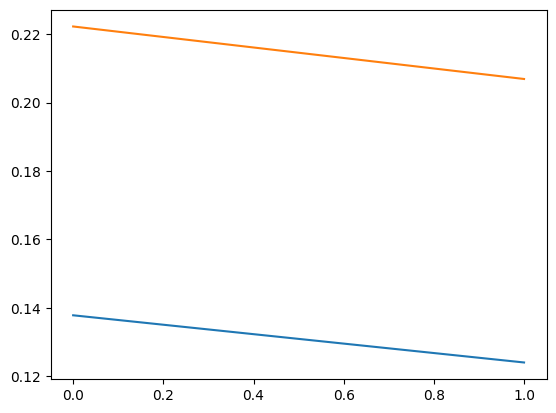

In [ ]:
plt.plot(hy.history['loss'][8:]) # 학습 손실값 시각화
plt.plot(hy.history['val_loss'][8:]) # 학습 손실값 시각화
plt.show() # loss값이 더 내려갈 거 같은데? 정확도까지 확인하자

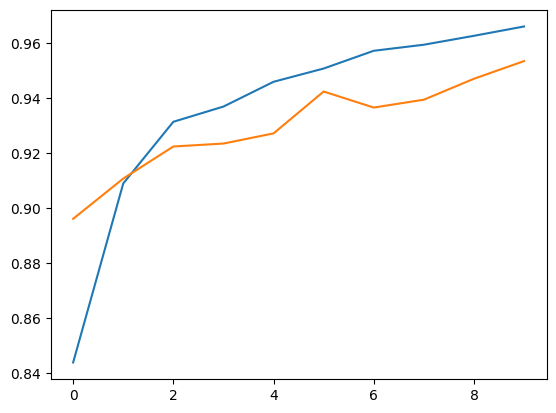

In [ ]:
plt.plot(hy.history['accuracy'])
plt.plot(hy.history['val_accuracy'])
plt.show() # 상승 추세에 있으니 좀 더 학습해도 될 것으로 보임

In [165]:
hy2 = m.fit(e_tr_x, e_tr_y, validation_data=(e_val_x, e_val_y), epochs=10)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9680 - loss: 0.1138 - val_accuracy: 0.9505 - val_loss: 0.2211
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9693 - loss: 0.1070 - val_accuracy: 0.9579 - val_loss: 0.1825
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9720 - loss: 0.0929 - val_accuracy: 0.9557 - val_loss: 0.1914
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9710 - loss: 0.1016 - val_accuracy: 0.9570 - val_loss: 0.1792
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9766 - loss: 0.0851 - val_accuracy: 0.9598 - val_loss: 0.2159
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9771 - loss: 0.0820 - val_accuracy: 0.9623 - val_loss: 0.1939
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9754 - loss: 0.0901 - val_accuracy: 0.9554 - val_loss: 0.2570
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9758 - loss: 0.0904 - 

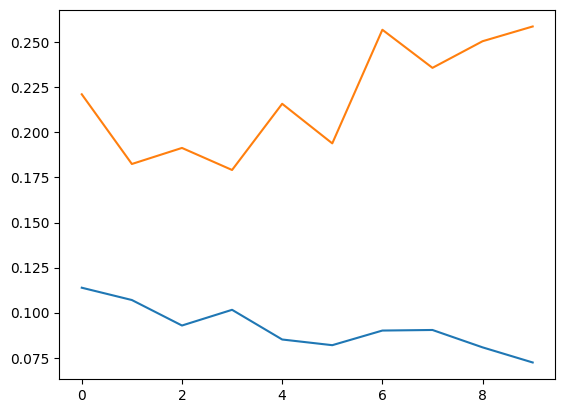

In [ ]:
plt.plot(hy2.history['loss']) # 학습 손실값 시각화
plt.plot(hy2.history['val_loss']) # 학습 손실값 시각화
plt.show() # 손실을 보면 좀 그런데..?

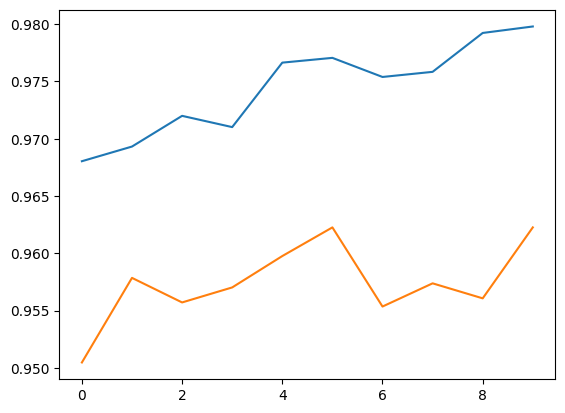

In [ ]:
plt.plot(hy2.history['accuracy'])
plt.plot(hy2.history['val_accuracy'])
plt.show() # 더 학습해도 괜찮을 거 같기도?

In [ ]:
# 다음은 콜백함수, 일부러 기울기 소실 후 배치정규화 등을 작업할 것임